In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 MB 81.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 26.1 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.3
    Uninstalling sympy-1.13.3:
      Successfully uninstalled sympy-1.13.3
Note: you may need to restart the kernel to use updated packages.


In [2]:
import data

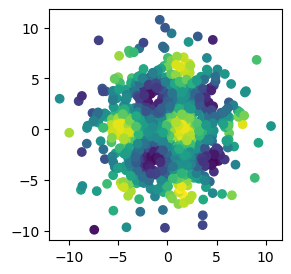

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.scatter(data.x_values, data.y_values, c=data.color_values)
plt.show()

In [7]:
import torch

model = torch.nn.Sequential(
    torch.nn.Linear(2,50),
    torch.nn.Sigmoid(),
    torch.nn.Linear(50,1)
)

In [11]:
loss_fn = torch.nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [13]:
for t in range(1000):
    y_pred = model(data.x)
    loss = loss_fn(y_pred, data.y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if t % 100 ==0:
        print(f"Iteration{t}, Loss:{loss.item()}")

Iteration0, Loss:0.9624567627906799
Iteration100, Loss:0.9092945456504822
Iteration200, Loss:0.8226365447044373
Iteration300, Loss:0.6866878867149353
Iteration400, Loss:0.5552436709403992
Iteration500, Loss:0.4580863416194916
Iteration600, Loss:0.3892900347709656
Iteration700, Loss:0.341106653213501
Iteration800, Loss:0.2978910207748413
Iteration900, Loss:0.2643732726573944


/srv/conda/lib/python3.11/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


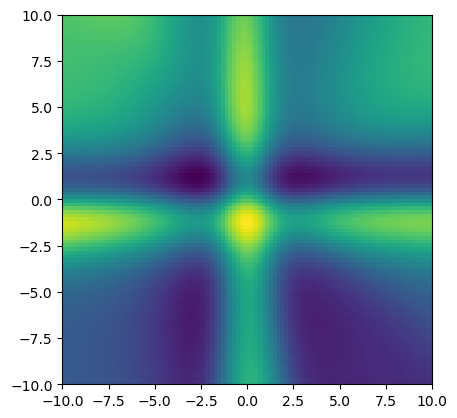

In [17]:
new_x = torch.linspace(-10,10,100)
grid = torch.stack(torch.meshgrid((new_x, new_x)), dim=2)

output = model(grid).detach()
plt.imshow(output, extent=(-10,10,-10,10))
plt.show()